In [269]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
# import umap.umap_ as umap
import umap.plot

In [270]:
root_dir=r'F:\jcy\humen_brain\electrophysiology\reconstruction\homer_reconstructed\img_procession'
morphology_feats=pd.read_csv(root_dir+'\\features_morphology.csv')
taget1=morphology_feats['region']
taget2=morphology_feats['morphology']
print(morphology_feats.columns)
morphology_features=morphology_feats.drop(['Height','Width','pixel_len','pixel_size','Filename','Soma_w','Soma_h','zoom_ratio','region','morphology'],axis='columns')
'''缺失值填充为该列上一个元素'''
morphology_features.fillna(method = 'pad', axis =0, inplace=True, limit=None)
summary_features=pd.DataFrame(morphology_features)
summary_features.head()

Index(['Height', 'Width', 'soma_surface_area', 'axon_total_length',
       'dentrite_exiting_soma', 'dentrite_total_length',
       'dentrite_mean_length', 'dentrite_node_number',
       'dentrite_ending_number', 'dendritic_field_area', 'pixel_size',
       'pixel_len', 'Filename', 'region', 'Soma_w', 'Soma_h', 'zoom_ratio',
       'morphology'],
      dtype='object')


,soma_surface_area,axon_total_length,dentrite_exiting_soma,dentrite_total_length,dentrite_mean_length,dentrite_node_number,dentrite_ending_number,dendritic_field_area
0,0.000044,0.139655,5,1.216379,0.243276,13,11,0.024149
1,0.000088,0.087162,4,1.236486,0.309122,12,14,0.016723
2,0.000068,0.123276,3,1.414655,0.471552,21,19,0.022984
3,0.000085,0.125862,5,1.071552,0.214310,14,14,0.015300
4,0.000096,0.080172,6,1.422414,0.237069,16,14,0.031521


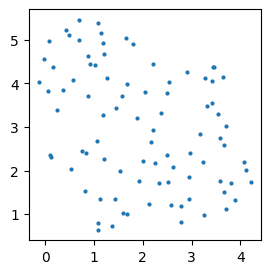

In [271]:
sum_fea_scaler=StandardScaler().fit_transform(summary_features)
sum_fea_scaler=pd.DataFrame(sum_fea_scaler,index=summary_features.index,columns=summary_features.columns)
umap_vals = umap.UMAP(n_neighbors=15,n_components=2).fit_transform(sum_fea_scaler)

plt.figure(figsize=(3,3))
plt.scatter(*umap_vals.T,s=4,edgecolors=None)
# sns.despine()

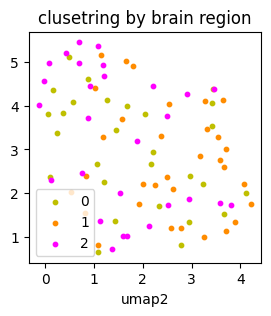

In [272]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
# sum_fea_scaler['tagets']=[i[:8] for i in sum_fea_scaler.index]
# tagets=sum_fea_scaler['tagets']
encoder = LabelEncoder()
taget1 = encoder.fit_transform(taget1)
encoder.classes_, np.unique(taget1, return_counts=True)
plt.figure(figsize=(3,3))
for color, i in zip(['y','darkorange','magenta'], [0, 1, 2]):
    plt.scatter(umap_vals[taget1==i, 0], umap_vals[taget1==i, 1],s=10, c=color, label=i)
    plt.legend()
plt.title('clusetring by brain region');plt.xlabel('umap1');plt.xlabel('umap2')
plt.savefig(root_dir+'\\clusetring by brain region.pdf')

(array(['BC'], dtype=object), array([88], dtype=int64))


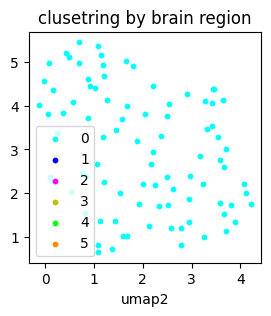

In [273]:
print(np.unique(taget2, return_counts=True))
encoder = LabelEncoder()
taget2 = encoder.fit_transform(taget2)
encoder.classes_, np.unique(taget2, return_counts=True)
plt.figure(figsize=(3,3))
for color, i in zip(['cyan','b','magenta','y','lime','darkorange',], [0, 1, 2,3,4,5]):
    plt.scatter(umap_vals[taget2==i, 0], umap_vals[taget2==i, 1],s=10, c=color, label=i)
    plt.legend()
plt.title('clusetring by brain region');plt.xlabel('umap1');plt.xlabel('umap2')
plt.savefig(root_dir+'\\clusetring by morphology.pdf')

Index(['soma_surface_area', 'axon_total_length', 'dentrite_exiting_soma',
       'dentrite_total_length', 'dentrite_mean_length', 'dentrite_node_number',
       'dentrite_ending_number', 'dendritic_field_area'],
      dtype='object')


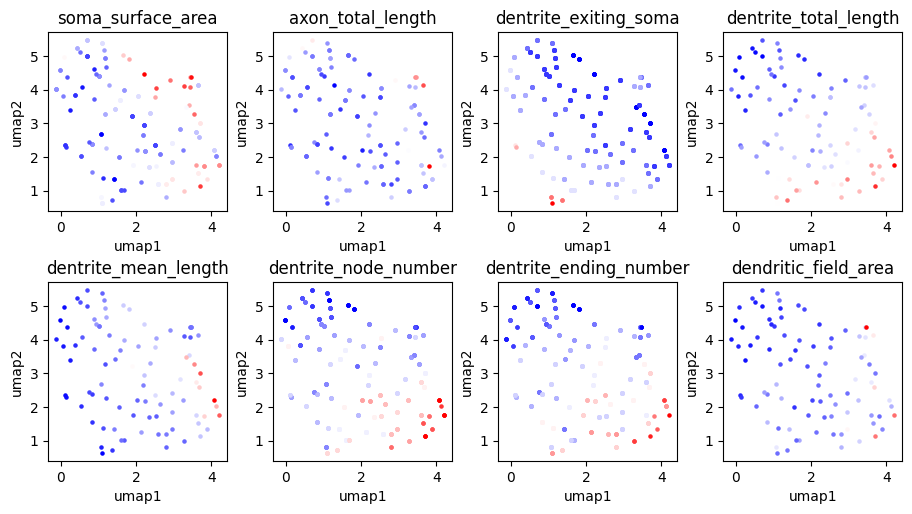

In [274]:
import numpy
import matplotlib.cm as cmap
###将颜色数值映射到颜色
parameters=sum_fea_scaler.columns
print(parameters)
plt.subplots(nrows=2, ncols=4, figsize=(9,5),constrained_layout=True)
for i in enumerate(parameters):
    r =sum_fea_scaler[i[1]].values
    c = cmap.bwr(numpy.int_((r-r.min())/r.ptp()*255))
    plt.subplot(2,4,i[0]+1)
    for color, cell in zip(c, r):
        plt.scatter(umap_vals[r==cell, 0], umap_vals[r==cell, 1],s=5, c=np.array(color).reshape(1,-1))
    plt.title(i[1]);plt.xlabel('umap1');plt.ylabel('umap2')
plt.savefig(root_dir+'\\clusetring by parameters.pdf')